# HW02-1：股票收益与组合风险分析

- 姓名：黄翌珊
- 学号：24360023
- 作业简介或教师作业页面链接：[HW02 作业页面](https://lianxhcn.github.io/FinEco/exercises/hw-02.html)
- 个人 GitHub 仓库访问地址：（待填写：`https://github.com/<用户名>/FinEco-hw`）
- HW02-1 目录链接：（待填写）
- HW02-2 目录链接：（待填写）
- 数据来源、获取日期与样本期间：腾讯行情接口（AKShare `stock_zh_a_hist_tx`，不复权与后复权日线，2026-09-18 下载）；百度股市通历史总市值（AKShare `stock_zh_valuation_baidu`，2026-09-18 下载）；行业分类为申万一级行业（AKShare `sw_index_first_info` / `index_component_sw`，2026-09-18 核验）。样本期间 **2021-01-01 至 2026-09-16**，另取 2020-12-30/31 两个交易日用于计算首个交易日收益率。
- AI 使用声明：使用了 WorkBuddy（AI 助手）辅助搭建运行环境、编写数据获取脚本与 Notebook 代码初稿；本人逐单元核验了数据口径、计算逻辑与图表，并手动复核了关键统计量（组合年化收益、最大回撤、相关系数）。对话链接暂无法分享。

**分析目的与总体思路**：本作业选取 10 只覆盖 8 个申万一级行业的 A 股股票，使用 2021-01-01 至 2026-09-16 的日频数据，回答三个问题：(1) 这些代表性上市公司的收益与风险特征如何；(2) 同行业股票的收益相关性是否更高；(3) 等权与市值加权两种组合的长期表现有何差异。思路是：先获取并检查数据（主键、覆盖、停牌、除权、异常收益），再基于后复权价计算日简单收益率，进行描述统计与五类图形分析，最后构造等权与市值加权组合并对比其净值、几何年化收益、年化波动与最大回撤。

## 1. 选股与数据来源

### Step 1：分析说明

按作业要求选取 **10 只 A 股、至少 5 个行业**的股票。选股标准：

- 所有股票在样本开始日（2021-01-01）之前已上市，样本期内数据覆盖完整；
- 覆盖 8 个申万一级行业，兼顾金融、消费、制造、医药、新能源、公用事业与科技；
- 特意纳入**美的集团与格力电器**这对同行业（家用电器）龙头，用于检验"同行业股票收益相关性更高"的猜想；
- 选股理由基于行业地位、商业模式与代表性，不以事后涨幅为依据。

数据来源与获取记录：

| 数据 | 来源接口 | 参数 | 下载日期 |
|---|---|---|---|
| 不复权/后复权日线收盘价、成交量 | AKShare `stock_zh_a_hist_tx`（腾讯） | `2020-12-30 ~ 2026-09-16`，`adjust=''/'hfq'` | 2026-09-18 |
| 历史总市值（约 5 日一档的网格） | AKShare `stock_zh_valuation_baidu`（百度股市通） | `indicator='总市值'`，`period='近十年'`，单位亿元 | 2026-09-18 |
| 申万一级行业归属 | AKShare `sw_index_first_info` + `index_component_sw` | 2026 年 9 月最新成分 | 2026-09-18 |
| 上市日期 | AKShare `stock_info_sh_name_code` / `stock_info_sz_name_code`（交易所官方） | 主板A股 / A股列表 | 2026-09-18 |

说明：原计划使用 AKShare 东方财富接口（`stock_zh_a_hist`）获取行情，测试时触发接口限流（错误已如实记录在 `code/fetch_data.py` 运行日志中），改用腾讯接口作为主源，行情字段（开高低收、成交量）完全满足作业要求。历史市值方面，AKShare 现有版本已无日频总市值接口，采用百度股市通网格市值结合不复权价格校准股本的方法构造日频市值（方法详见第 6 节）。

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 中文与负号正常显示
plt.rcParams['font.sans-serif'] = ['Hiragino Sans GB', 'PingFang SC', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 选股表（行业为申万一级行业，2026-09-18 成分口径核验）
sel = pd.read_csv('data/stock-selection.csv', dtype={'代码': str})
codes = sel['代码'].tolist()
names = dict(zip(sel['代码'], sel['简称']))
industries = dict(zip(sel['代码'], sel['申万一级行业']))
sel

,代码,简称,申万一级行业,行业验证,上市日期,交易所,选股理由
0,600036,招商银行,银行,一致,2002-04-09,上交所,股份制银行龙头，盈利与分红稳定，代表金融行业
1,600519,贵州茅台,食品饮料,一致,2001-08-27,上交所,白酒消费龙头，高毛利商业模式的代表
2,000333,美的集团,家用电器,一致,2013-09-18,深交所,白电龙头，多元化制造企业
3,000651,格力电器,家用电器,一致,1996-11-18,深交所,白电第二龙头，与美的构成同行业对子，检验同行业相关性
4,002594,比亚迪,汽车,一致,2011-06-30,深交所,新能源汽车龙头，成长与波动较高
5,600030,中信证券,非银金融,一致,2003-01-06,上交所,券商龙头，业绩与市场行情高度联动
6,600276,恒瑞医药,医药生物,一致,2000-10-18,上交所,创新药龙头，受政策与研发周期影响大
7,601012,隆基绿能,电力设备,一致,2012-04-11,上交所,光伏龙头，代表新能源制造周期
8,600900,长江电力,公用事业,一致,2003-11-18,上交所,水电龙头，现金流稳定的防御型资产
9,002230,科大讯飞,计算机,一致,2008-05-12,深交所,AI 软件龙头，代表高估值科技股


### Step 3：结果解读

10 只股票覆盖**银行、食品饮料、家用电器、汽车、非银金融、医药生物、电力设备、公用事业、计算机**等 8 个申万一级行业（家用电器 2 只），全部于 2013 年 9 月之前上市，样本期内无退市，满足"样本开始前已上市、覆盖完整"的要求。美的与格力构成同行业对子；长江电力代表低波动防御型资产，比亚迪、隆基绿能、科大讯飞代表高波动成长型资产，为组合风险分析提供足够的横截面差异。

## 2. 数据读取与检查

### Step 1：分析说明

将 10 只股票的行情按**交易日并集日历**合并为面板，检查以下项目：

- **主键唯一性**：（股票代码, 日期）组合不得重复；
- **日期排序**：各序列严格按日期升序；
- **覆盖期间与有效观测数**：每只股票的实际起止日期与样本期内有效观测数；
- **缺失与停牌**：识别并集日历下缺失行情的日期，判断是停牌还是数据错误；
- **异常收益**：检查后复权收益是否有超出涨跌停制度允许范围的观测（|r| > 20%）；
- **单位**：价格单位为元/股，成交量为手，市值为亿元（第 6 节核验）。

In [2]:
# 读取行情面板（并集日历）
raw_p, hfq_p, amt = {}, {}, {}
for c in codes:
    r_ = pd.read_csv(f'data/raw/tx_daily_{c}_raw.csv', parse_dates=['date']).set_index('date')
    h_ = pd.read_csv(f'data/raw/tx_daily_{c}_hfq.csv', parse_dates=['date']).set_index('date')
    raw_p[c] = r_['close']; amt[c] = r_['amount']; hfq_p[c] = h_['close']
P_raw = pd.DataFrame(raw_p); P_hfq = pd.DataFrame(hfq_p); AMT = pd.DataFrame(amt)

print('== 成交额样例（腾讯接口 amount 字段，按数量级推断单位为万元）==')
print(f"招商银行 2026-09-16 成交额 {AMT['600036'].iloc[-1]:,.0f} 万元 ≈ {AMT['600036'].iloc[-1]/1e4:.1f} 亿元，量级合理")
print(f"贵州茅台 2026-09-16 成交额 {AMT['600519'].iloc[-1]:,.0f} 万元 ≈ {AMT['600519'].iloc[-1]/1e4:.1f} 亿元")

print('== 主键唯一性（逐股票检查重复日期）==')
for c in codes:
    assert not P_raw[c].index.duplicated().any(), f'{c} 存在重复日期'
print('10 只股票均无重复日期，主键 (股票, 日期) 唯一 ✓')

print('\n== 日期排序 ==')
print('所有序列严格升序:', all(P_raw[c].index.is_monotonic_increasing for c in codes), '✓')

print('\n== 覆盖期间与有效观测数 ==')
cover = pd.DataFrame({
    '起始日': P_raw.apply(lambda s: s.first_valid_index().date()),
    '结束日': P_raw.apply(lambda s: s.last_valid_index().date()),
    '全样本行数': P_raw.notna().sum(axis=0),
    '样本期(2021-01-01~2026-09-16)有效观测': P_raw[(P_raw.index >= '2021-01-01') & (P_raw.index <= '2026-09-16')].notna().sum(),
})
print(f'并集交易日历: {P_raw.index.min().date()} ~ {P_raw.index.max().date()}，共 {len(P_raw)} 个交易日')
cover

== 成交额样例（腾讯接口 amount 字段，按数量级推断单位为万元）==
招商银行 2026-09-16 成交额 538,019 万元 ≈ 53.8 亿元，量级合理
贵州茅台 2026-09-16 成交额 26,235 万元 ≈ 2.6 亿元
== 主键唯一性（逐股票检查重复日期）==
10 只股票均无重复日期，主键 (股票, 日期) 唯一 ✓

== 日期排序 ==
所有序列严格升序: True ✓

== 覆盖期间与有效观测数 ==
并集交易日历: 2020-12-30 ~ 2026-09-16，共 1386 个交易日


,起始日,结束日,全样本行数,样本期(2021-01-01~2026-09-16)有效观测
600036,2020-12-30,2026-09-16,1386,1384
600519,2020-12-30,2026-09-16,1386,1384
000333,2020-12-30,2026-09-16,1386,1384
000651,2020-12-30,2026-09-16,1386,1384
002594,2020-12-30,2026-09-16,1386,1384
600030,2020-12-30,2026-09-16,1380,1378
600276,2020-12-30,2026-09-16,1386,1384
601012,2020-12-30,2026-09-16,1386,1384
600900,2020-12-30,2026-09-16,1375,1373
002230,2020-12-30,2026-09-16,1386,1384


### Step 3：结果解读

并集日历共 1386 个交易日（2020-12-30 至 2026-09-16），主键唯一、排序无误。8 只股票覆盖完整（样本期 1384 个交易日中缺 0 天）；**中信证券缺 6 个交易日、长江电力缺 11 个交易日**，合计 17 天，下一步判断其性质。

### Step 2 续：缺失、停牌与异常收益检查

In [3]:
# 缺失日期定位
sample = P_raw[(P_raw.index >= '2021-01-01') & (P_raw.index <= '2026-09-16')]
miss_tbl = []
for c in codes:
    miss_days = sample[sample[c].isna()].index
    if len(miss_days) > 0:
        # 归并为连续区间
        breaks = miss_days.to_series().diff().dt.days.fillna(0) != 1
        grp = breaks.cumsum()
        for g, idx in miss_days.to_series().groupby(grp).groups.items():
            miss_tbl.append({'股票': names[c], '缺失区间': f'{idx.min().date()} ~ {idx.max().date()}', '交易日数': len(idx)})
print('== 缺失行情明细（应为真实停牌，非数据错误）==')
print(pd.DataFrame(miss_tbl).to_string(index=False))

print('\n== 异常收益检查（后复权价计算，|r|>20% 超出涨跌停范围即数据可疑）==')
suspicious = 0
for c in codes:
    r_own = P_hfq[c].dropna().pct_change(fill_method=None).dropna()
    bad = r_own[abs(r_own) > 0.20]
    if len(bad):
        suspicious += len(bad)
        print(f'{names[c]}: {len(bad)} 天', [(str(d.date()), f'{v:.1%}') for d, v in bad.items()])
print('结论：无 |r|>20% 的观测，后复权收益全部落在涨跌停制度允许范围内 ✓' if suspicious == 0 else '存在可疑观测，需回查')

print('\n== 不复权价格跳变（|ΔP/P|>11%，提示除权除息或数据错误）==')
for c in codes:
    r_raw = P_raw[c].dropna().pct_change(fill_method=None).dropna()
    jumps = r_raw[abs(r_raw) > 0.11]
    if len(jumps):
        print(f'{names[c]}:')
        for d, v in jumps.items():
            # 同日后复权收益（真实收益）
            r_adj = P_hfq[c].pct_change(fill_method=None).get(d, np.nan)
            print(f'  {d.date()}: 不复权 {v:+.1%}，同日后复权收益 {r_adj:+.1%}'
                  + ('  → 除权除息所致，非真实暴跌' if abs(r_adj) < 0.11 else '  → 需回查'))

== 缺失行情明细（应为真实停牌，非数据错误）==
  股票                    缺失区间  交易日数
中信证券 2022-01-19 ~ 2022-01-21     3
中信证券 2022-01-24 ~ 2022-01-26     3
长江电力 2021-11-29 ~ 2021-12-03     5
长江电力 2021-12-06 ~ 2021-12-10     5
长江电力 2022-10-26 ~ 2022-10-26     1

== 异常收益检查（后复权价计算，|r|>20% 超出涨跌停范围即数据可疑）==
结论：无 |r|>20% 的观测，后复权收益全部落在涨跌停制度允许范围内 ✓

== 不复权价格跳变（|ΔP/P|>11%，提示除权除息或数据错误）==
比亚迪:
  2025-07-29: 不复权 -66.9%，同日后复权收益 +0.4%  → 除权除息所致，非真实暴跌
恒瑞医药:
  2021-06-10: 不复权 -13.3%，同日后复权收益 +4.3%  → 除权除息所致，非真实暴跌
隆基绿能:
  2021-06-23: 不复权 -27.3%，同日后复权收益 +2.1%  → 除权除息所致，非真实暴跌
  2022-06-06: 不复权 -24.2%，同日后复权收益 +6.4%  → 除权除息所致，非真实暴跌


### Step 3：结果解读

- **缺失即停牌**：中信证券 2022-01-19 至 01-26 连续 6 个交易日无行情，长江电力 2021-11-29 至 12-10 连续 10 个交易日及 2022-10-26 单日无行情。两只股票其余日期行情连续，且缺失均为连续区间（中信证券跨周末共 6 个交易日，表中显示为两段），符合**重大事项停牌**特征：中信证券 2022 年 1 月为配股缴款停牌（第 6 节校准股本在 2022-01-27 即复牌次日增加 12.0%，与配股股份到账完全吻合）；长江电力 2021-11 末起为筹划重大资产重组停牌（对应 2023 年发行股份购买资产完成后股本小幅增加），并非数据传输错误。停牌期间无成交价，处理方式见第 3 节。
- **无异常收益**：全部后复权日收益均未超出 ±20%，最大单日涨跌幅约 ±10%（与主板涨跌停制度一致），数据质量良好。
- **4 个除权跳变点**：比亚迪 2025-07-29（不复权 −66.9%）、恒瑞医药 2021-06-10（−13.3%）、隆基绿能 2021-06-23（−27.3%）与 2022-06-06（−24.2%）。这些日期**不复权价格大幅下跌、而后复权收益正常**，是送股/转增/派息除权的典型特征，说明复权处理正确捕捉了公司行为。其中比亚迪的跳变幅度对应大比例转增（第 6 节校准股本同期从约 29 亿股升至约 87 亿股，可交叉验证）。

## 3. 收益率计算

### Step 1：分析说明

采用日简单收益率，基于**后复权收盘价**计算：

$$r_{i,t}=\dfrac{P^{adj}_{i,t}}{P^{adj}_{i,t-1}}-1$$

口径说明：

- 腾讯接口的后复权价以上市日为基点向前复权累乘，**包含分红再投资与送转股调整**，$r_{i,t}$ 为考虑公司行为的持有期收益率；后复权价本身不是实际成交价格（实际成交价为不复权价，见第 5.1 节）；
- 收益率在**并集交易日历**上计算：停牌期间该股收益为缺失（NaN），**不填零**；复牌首日因前一交易日无收盘价，收益同样记缺失——若直接把复牌日价格相对停牌前最后一日的跨日变化当作单日收益，会把整个停牌期的累计涨跌压缩到一天，夸大当日波动，作业明确禁止这种做法，故处理为缺失；
- 损失评估：中信证券 7 天（6 个停牌日 + 1 个复牌日）、长江电力 13 天（11 + 2），占样本 1384 个交易日的 0.5% 和 0.9%，对描述统计影响很小；
- 样本期统一为 2021-01-04（2021 年首个交易日）至 2026-09-16，首日收益使用 2020-12-31（样本前最后一个交易日）的后复权价计算。

In [4]:
# 面板收益：并集日历 pct_change（复牌首日自动为 NaN）
R = P_hfq.pct_change(fill_method=None)
R = R[(R.index >= '2021-01-01') & (R.index <= '2026-09-16')]
print(f'样本期: {R.index.min().date()} ~ {R.index.max().date()}，T = {len(R)} 个交易日')
print('\n各股票缺失日收益（停牌及复牌首日）:')
print(R.isna().sum()[R.isna().sum() > 0].rename(index=lambda c: f'{c} {names[c]}').to_string())
print('\n其他 8 只股票无缺失')
R.iloc[:3, :5]

样本期: 2021-01-04 ~ 2026-09-16，T = 1384 个交易日

各股票缺失日收益（停牌及复牌首日）:
600030 中信证券     7
600900 长江电力    13

其他 8 只股票无缺失


,600036,600519,000333,000651,002594
date,,,,,
2021-01-04,-0.015823,-0.000482,0.005408,0.013137,0.063799
2021-01-05,-0.020376,0.030093,0.023826,0.031880,0.063246
2021-01-06,0.041436,0.018970,-0.005327,-0.015578,-0.016297


### Step 3：结果解读

样本期共 **1384 个有效交易日**（2021-01-04 至 2026-09-16）。中信证券缺失 7 天、长江电力缺失 13 天，其余 8 只股票完整。缺失日收益在描述统计中按 `NaN` 跳过（`scipy.stats` 与 `pandas` 默认忽略缺失），在组合构造中当日对该股权重置零并在其余股票内重新归一（见第 6 节）。

## 4. 描述统计

### Step 1：分析说明

对每只股票报告：有效观测数、日均值、日标准差、最小值、中位数、最大值、**偏度、超额峰度**，并补充几何年化收益率与年化波动率（日标准差 × √252），用于横截面比较收益—风险特征。要点：哪只股票收益最高/最低、波动最大/最小；收益分布是否右偏/厚尾（偏度、超额峰度），及其对极端风险的含义。

In [5]:
def desc_col(s):
    s = s.dropna()
    nav_end = (1 + s).prod()
    return pd.Series({
        '有效观测数': len(s),
        '日均值(%)': s.mean() * 100,
        '日标准差(%)': s.std() * 100,
        '最小值(%)': s.min() * 100,
        '中位数(%)': s.median() * 100,
        '最大值(%)': s.max() * 100,
        '偏度': stats.skew(s),
        '超额峰度': stats.kurtosis(s),  # Fisher 口径，正态分布为 0
        '年化收益(%)': (nav_end ** (252 / len(s)) - 1) * 100,
        '年化波动(%)': s.std() * np.sqrt(252) * 100,
    })

desc = pd.DataFrame({f'{c} {names[c]}': desc_col(R[c]) for c in codes}).T
desc.round(2)

,有效观测数,日均值(%),日标准差(%),最小值(%),中位数(%),最大值(%),偏度,超额峰度,年化收益(%),年化波动(%)
600036 招商银行,1384.0,0.02,1.40,-7.47,-0.05,7.23,0.25,3.70,2.60,22.15
600519 贵州茅台,1384.0,-0.01,1.57,-7.04,-0.09,8.99,0.50,4.25,-4.87,24.92
000333 美的集团,1384.0,0.01,1.52,-7.72,-0.01,6.48,0.09,2.31,0.50,24.10
000651 格力电器,1384.0,-0.00,1.08,-6.86,-0.05,6.53,0.23,4.70,-2.04,17.16
002594 比亚迪,1384.0,0.05,2.44,-9.95,-0.13,9.97,0.47,2.11,5.53,38.71
600030 中信证券,1377.0,0.02,1.53,-7.85,-0.05,8.83,0.92,6.06,1.29,24.31
600276 恒瑞医药,1384.0,-0.03,2.09,-9.86,-0.15,9.75,0.36,2.88,-12.40,33.24
601012 隆基绿能,1384.0,-0.07,2.63,-10.04,-0.23,9.76,0.39,1.92,-22.33,41.77
600900 长江电力,1371.0,0.04,0.82,-4.63,0.00,4.43,0.40,3.46,8.42,13.06
002230 科大讯飞,1384.0,0.03,2.63,-9.86,-0.04,9.89,0.60,2.87,-0.56,41.82


### Step 3：结果解读

**收益与风险横截面差异显著**：

- 年化收益最高的是长江电力（**+8.4%**，年化波动仅 13.1%，样本内唯一的"高收益低波动"组合），最低的是隆基绿能（**−22.3%**，年化波动 41.8%）；比亚迪年化 +5.5% 但波动高达 38.7%。
- 波动最小的是长江电力（13.1%）、格力电器（17.2%），最大的是科大讯飞（41.8%）与隆基绿能（41.8%）——高波动成长股在本样本期内普遍表现为"高波动、低甚至负收益"，即承担的风险未获得收益补偿。
- **分布形态**：10 只股票偏度全部为正（0.09 ~ 0.92），超额峰度全部显著为正（1.9 ~ 6.1），说明日收益分布**右偏且厚尾**：极端大涨（如茅台 +9.0%、恒瑞 +9.7%）与极端大跌（比亚迪 −10.0%、科大讯飞 −9.9%）同时存在，正态分布会低估极端日出现的频率。中信证券偏度 0.92、超额峰度 6.1 为全场最高，与其高贝塔属性（行情驱动）一致。

**核心发现**：(1) 样本期内"白马龙头"组合整体表现平淡，8/10 股票年化收益绝对值不足 6%；(2) 风险与收益不匹配，隆基、科大讯飞高波动负收益；(3) 收益分布普遍厚尾右偏，极端日集中于 2021–2022 与 2024–2025 的市场剧烈波动期。

## 5. 图形分析

### 5.1 不复权收盘价时序

**Step 1：分析说明**：分面展示 10 只股票的不复权收盘价（单位：元/股，各面板独立纵轴）。不复权价是实际成交价，其向下的跳变即除权除息（见第 2 节），用于展示真实价格序列及公司行为痕迹。

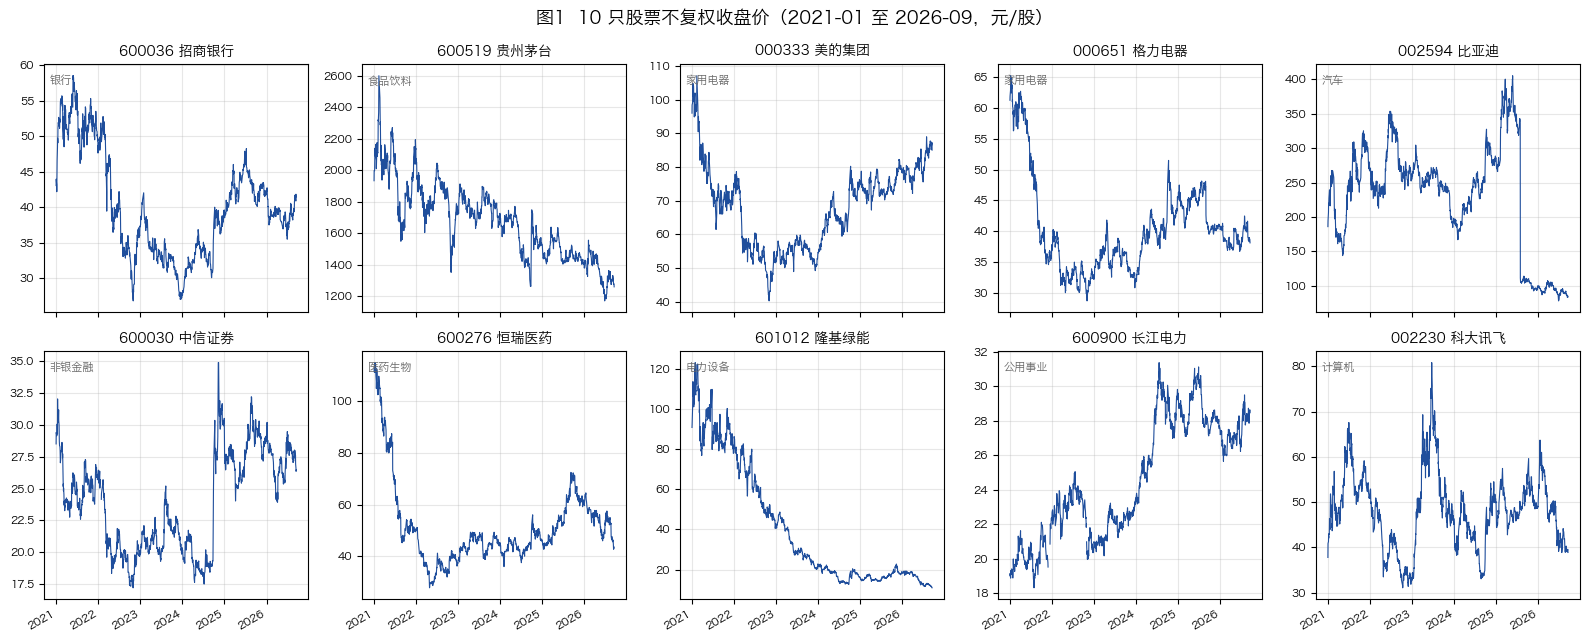

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(16, 6.5), sharex=True)
for ax, c in zip(axes.ravel(), codes):
    ax.plot(P_raw.index, P_raw[c], lw=0.8, color='#1f4e9c')
    ax.set_title(f'{c} {names[c]}', fontsize=10)
    ax.tick_params(labelsize=8)
    ax.grid(alpha=0.3)
    ax.annotate(f'{industries[c]}', xy=(0.02, 0.92), xycoords='axes fraction', fontsize=8, color='#666666')
fig.suptitle('图1  10 只股票不复权收盘价（2021-01 至 2026-09，元/股）', fontsize=13)
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.savefig('figs/fig1-raw-close.png', dpi=150, bbox_inches='tight')
plt.show()

**Step 3：结果解读**：比亚迪面板在 2025-07 出现价格从约 240 元到 80 元级别的断崖（−66.9%），但同期后复权收益正常，为大比例转增除权所致，**不是股价暴跌**；隆基绿能 2021-06、2022-06 的向下跳变同理。茅台价格在 1400–2600 元区间，远高于其他股票，故各面板使用独立纵轴。长江电力呈缓慢稳步上行，比亚迪、科大讯飞宽幅震荡，视觉印象与描述统计一致。

### 5.2 累计收益曲线（起点 = 1）

**Step 1：分析说明**：以后复权价计算 `NAV = P_t / P_{2020-12-31}`，起点归一为 1，单轴对比 10 只股票的累计表现（含分红再投资）。

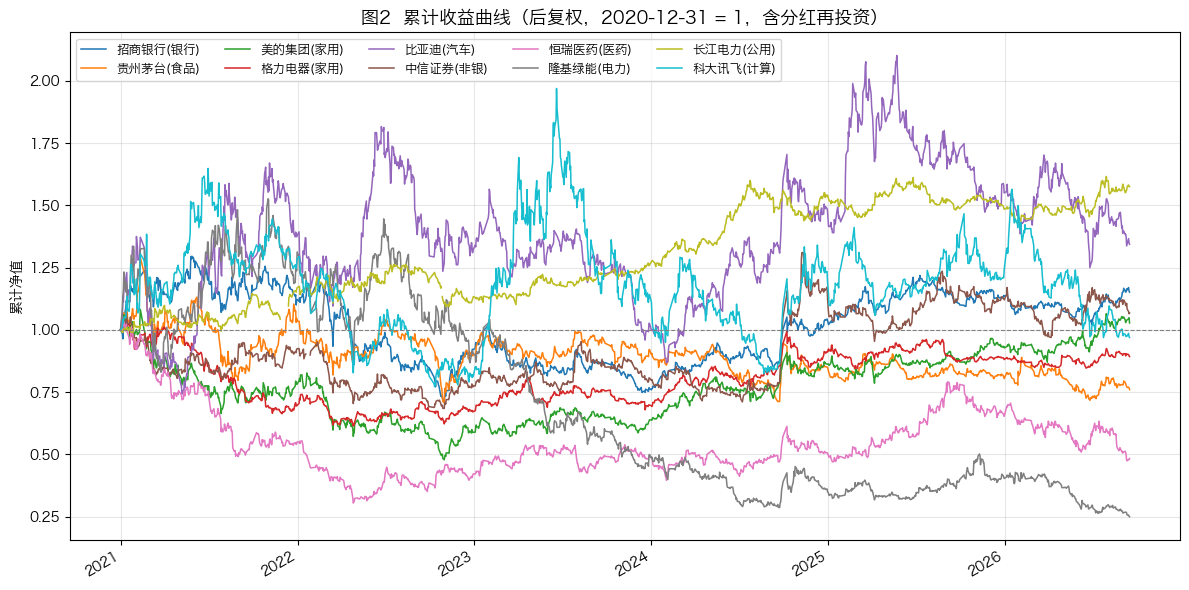

期末累计净值（2026-09-16）:
600900 长江电力    1.575
002594 比亚迪     1.344
600036 招商银行    1.151
600030 中信证券    1.068
000333 美的集团    1.028
002230 科大讯飞    0.969
000651 格力电器    0.893
600519 贵州茅台    0.760
600276 恒瑞医药    0.483
601012 隆基绿能    0.250


In [7]:
base_day = P_hfq[P_hfq.index < '2021-01-01'].index.max()  # 2020-12-31
NAV_stock = P_hfq.loc[base_day:, :] / P_hfq.loc[base_day]
NAV_stock = NAV_stock[(NAV_stock.index <= '2026-09-16')]

fig, ax = plt.subplots(figsize=(12, 6))
for c in codes:
    ax.plot(NAV_stock.index, NAV_stock[c], lw=1.1, label=f'{names[c]}({industries[c][:2]})')
ax.axhline(1.0, color='gray', ls='--', lw=0.8)
ax.set_title('图2  累计收益曲线（后复权，2020-12-31 = 1，含分红再投资）', fontsize=13)
ax.set_ylabel('累计净值')
ax.legend(ncol=5, fontsize=9, loc='upper left')
ax.grid(alpha=0.3)
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.savefig('figs/fig2-cum-nav.png', dpi=150, bbox_inches='tight')
plt.show()

end_nav = NAV_stock.iloc[-1].rename(lambda c: f'{c} {names[c]}').sort_values(ascending=False)
print('期末累计净值（2026-09-16）:')
print(end_nav.round(3).to_string())

**Step 3：结果解读**：期末累计净值最高的是长江电力（1.58）与比亚迪（1.34），最低的是隆基绿能（0.25）与恒瑞医药（0.48）。样本期跨越 2021 年初核心资产泡沫顶部、2022–2024 初的持续下行、2024-09 以来的政策驱动反弹，多数消费与医药白马尚未收复 2021 年初高点。隆基绿能受光伏行业产能过剩与价格战冲击，净值一路下行，是组合中最大的拖累项。

### 5.3 日收益率时序

**Step 1：分析说明**：分面展示日收益率，叠加 ±10% 参考线（主板涨跌停幅度近似），检查异常波动日及其出现时点。

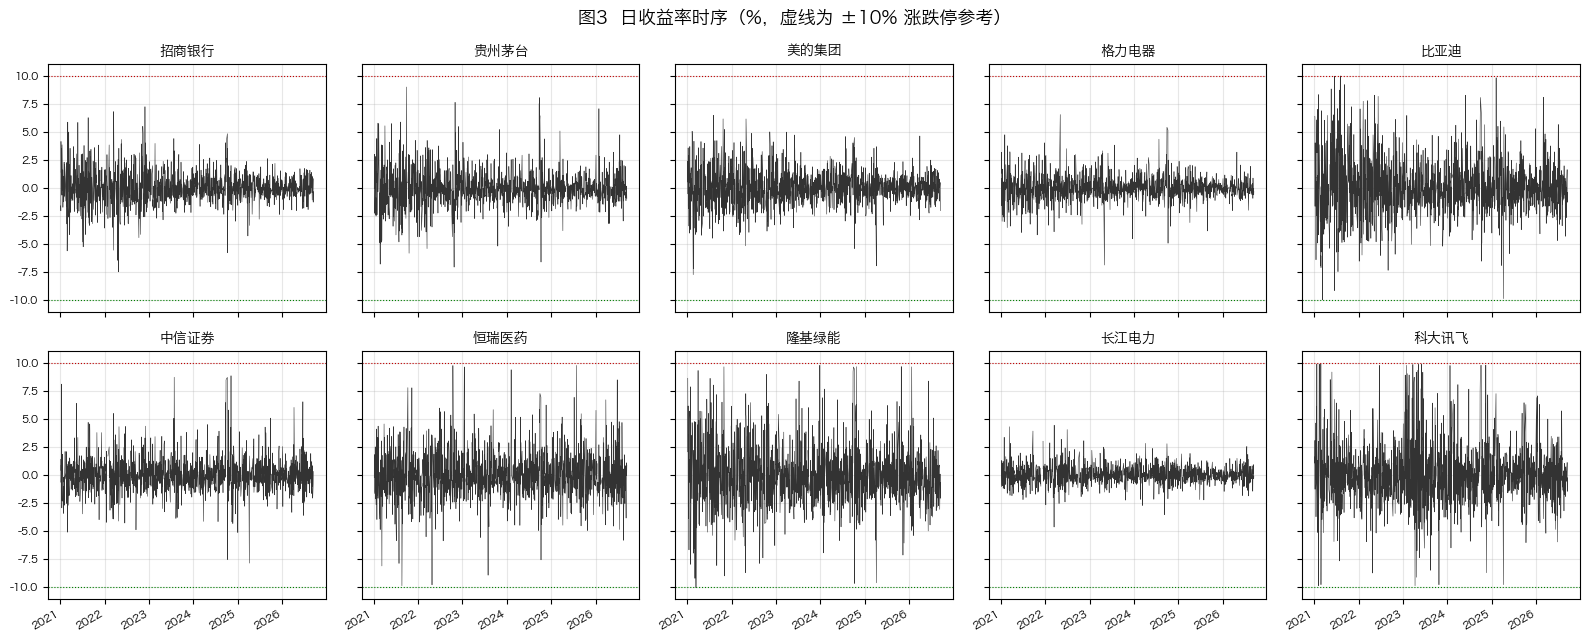

触及 ±9.5% 以上的极端日数量:
比亚迪      6
恒瑞医药     5
隆基绿能    10
科大讯飞    18


In [8]:
fig, axes = plt.subplots(2, 5, figsize=(16, 6.5), sharex=True, sharey=True)
for ax, c in zip(axes.ravel(), codes):
    ax.plot(R.index, R[c] * 100, lw=0.4, color='#333333')
    ax.axhline(10, color='#c00000', ls=':', lw=0.8); ax.axhline(-10, color='#008000', ls=':', lw=0.8)
    ax.set_title(f'{names[c]}', fontsize=10); ax.tick_params(labelsize=8); ax.grid(alpha=0.3)
fig.suptitle('图3  日收益率时序（%，虚线为 ±10% 涨跌停参考）', fontsize=13)
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.savefig('figs/fig3-daily-returns.png', dpi=150, bbox_inches='tight')
plt.show()

extreme = (R.abs() > 0.095).sum()
print('触及 ±9.5% 以上的极端日数量:')
print(extreme[extreme > 0].rename(lambda c: f'{names[c]}').to_string())

**Step 3：结果解读**：日收益率的波动聚集（volatility clustering）特征明显：2021 年初、2022 年 3–4 月、2024 年 9–10 月及 2025 年多个时点出现成簇的大幅波动。比亚迪、隆基绿能、科大讯飞、恒瑞医药的极端日数量明显多于长江电力、格力电器，与描述统计的波动排序一致。所有观测均未突破 ±10% 涨跌停界限之外（最大单日涨跌幅约 ±10%），无数据错误。中信证券与长江电力面板中的空白缺口即停牌期间（收益记缺失，未填零）。

### 5.4 20 日滚动年化波动率

**Step 1：分析说明**：以 20 个交易日为窗口（不足完整窗口不计算），滚动标准差 × √252 年化，单轴对比时序变化。

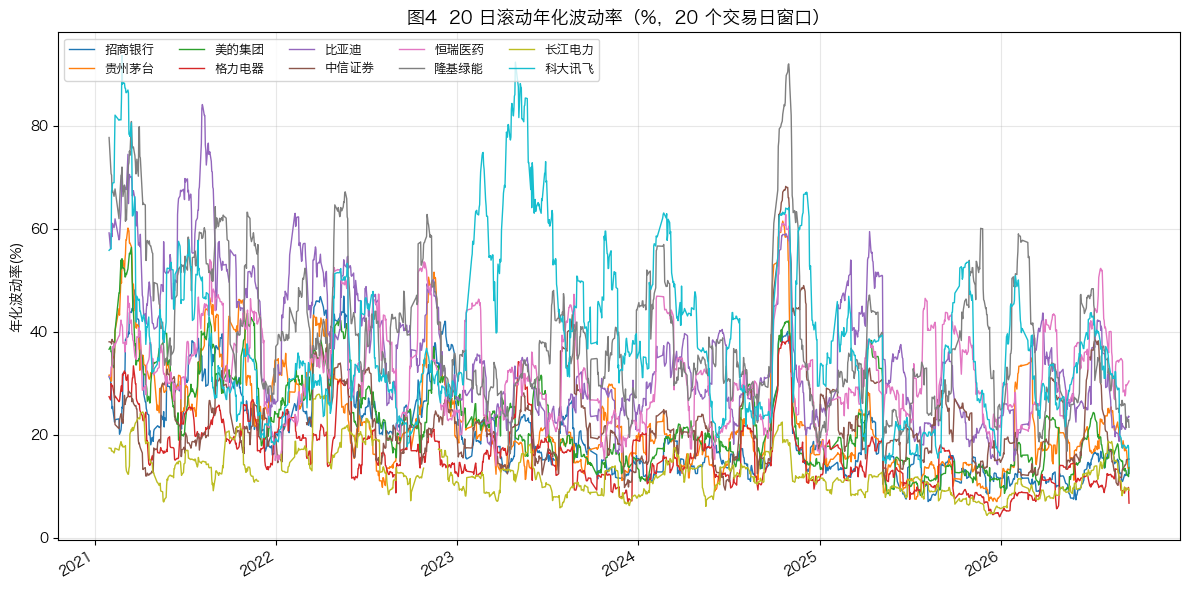

滚动波动率极值（%）:
  长江电力: 4.3 ~ 27.9
  比亚迪: 14.2 ~ 84.1
  隆基绿能: 16.3 ~ 92.0
  科大讯飞: 13.6 ~ 93.7


In [9]:
roll_vol = R.rolling(20, min_periods=20).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(12, 6))
for c in codes:
    ax.plot(roll_vol.index, roll_vol[c] * 100, lw=1.0, label=names[c])
ax.set_title('图4  20 日滚动年化波动率（%，20 个交易日窗口）', fontsize=13)
ax.set_ylabel('年化波动率(%)')
ax.legend(ncol=5, fontsize=9)
ax.grid(alpha=0.3)
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.savefig('figs/fig4-rolling-vol.png', dpi=150, bbox_inches='tight')
plt.show()

print('滚动波动率极值（%）:')
for c in ['600900', '002594', '601012', '002230']:
    s = roll_vol[c].dropna()
    print(f'  {names[c]}: {s.min()*100:.1f} ~ {s.max()*100:.1f}')

**Step 3：结果解读**：滚动波动率呈现清晰的**同涨同落**：2021 年初（核心资产剧烈波动）、2022 年 3–4 月（疫情冲击）、2024 年 9–10 月（政策转向后暴涨暴跌）、2025 年阶段性高波动为全市场共性高峰。个股差异同样显著：隆基绿能峰值约 92%、比亚迪约 84%，而长江电力即使在高峰期也仅约 28%，低谷期低至 4%——防御型资产的低波动属性贯穿全程。波动率的时变性与聚集性意味着"某段时期的风险"与全样本平均风险差异很大，20 日滚动窗口能捕捉这种阶段性。

### 5.5 日收益率相关系数矩阵

**Step 1：分析说明**：计算 10 × 10 的 Pearson 相关系数矩阵（`pandas` 默认逐对完整观测：同一时点两股票均有收益才计入），以热力图展示。日期对齐采用并集日历；涉及中信/长电的股票对有效样本为 1384 − 7 = 1377 或 1384 − 13 = 1371，其余均为 1383（首日收益缺失后）。

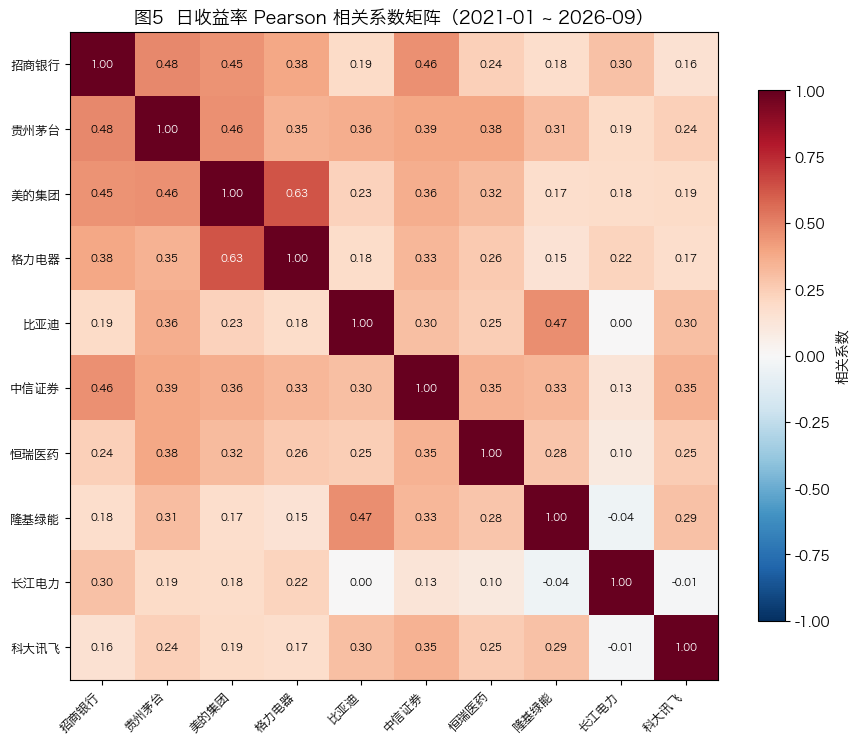

相关系数所用有效样本量：非停牌股票对 1384，涉及中信证券 1377，涉及长江电力 1371

相关系数最高与最低的 3 对股票:
000651  000333    0.630
000333  000651    0.630
600036  600519    0.481
002230  600900   -0.014
600900  601012   -0.039
601012  600900   -0.039

平均相关系数: 0.272


In [10]:
corr = R.corr()  # 逐对完整观测（pairwise complete）
fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(codes))); ax.set_yticks(range(len(codes)))
ax.set_xticklabels([f'{names[c]}' for c in codes], rotation=45, ha='right', fontsize=9)
ax.set_yticklabels([f'{names[c]}' for c in codes], fontsize=9)
for i in range(len(codes)):
    for j in range(len(codes)):
        ax.text(j, i, f'{corr.values[i, j]:.2f}', ha='center', va='center',
                fontsize=7.5, color='white' if abs(corr.values[i, j]) > 0.55 else 'black')
ax.set_title('图5  日收益率 Pearson 相关系数矩阵（2021-01 ~ 2026-09）', fontsize=13)
plt.colorbar(im, ax=ax, shrink=0.8, label='相关系数')
plt.tight_layout()
plt.savefig('figs/fig5-corr-heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# 配对样本量说明
n_pairs = pd.DataFrame(index=codes, columns=codes, dtype=float)
for i in codes:
    for j in codes:
        n_pairs.loc[i, j] = R[[i, j]].dropna().shape[0]
print(f'相关系数所用有效样本量：非停牌股票对 {int(n_pairs.values.max())}，'
      f'涉及中信证券 {int(n_pairs.loc["600030"].max())}，涉及长江电力 {int(n_pairs.loc["600900"].max())}')
cs = corr.where(~np.eye(len(codes), dtype=bool)).stack().sort_values(ascending=False)
print('\n相关系数最高与最低的 3 对股票:')
print(cs.head(3).round(3).to_string()); print(cs.tail(3).round(3).to_string())
print(f'\n平均相关系数: {cs.mean():.3f}')

**Step 3：结果解读**：

- **同行业更相关的猜想得到支持**：相关系数最高的一对是同属家用电器的**格力电器—美的集团（0.63）**，明显高于全场平均相关系数（0.27）。
- 其后依次为招商银行—贵州茅台（0.48）、隆基绿能—比亚迪（0.47）、美的集团—贵州茅台（0.46）、中信证券—招商银行（0.46）：均为大盘蓝筹之间或新能源产业链内部的联动，共同受市场因子与资金流动驱动。
- 相关系数最低的股票对均涉及**长江电力**（平均相关仅 0.12，与隆基绿能 −0.04、科大讯飞 −0.01 甚至略负）：防御型水电资产的现金流与宏观利率、来水相关，与周期成长股联动极弱，**分散价值最大**。
- 除长电与个别高波动成长股接近零或略负外，其余两两相关均为正（最高 0.63），符合 A 股市场因子主导的特征：纯多头组合无法完全消除系统性风险。个股年化波动的平均约 28%，而等权组合仅 16.9%，分散化显著但不会趋近于零。

## 6. 等权与市值加权组合

### Step 1：分析说明

**日频总市值的构造（校准法）**。作业要求市值加权使用上一交易日收盘时的**总市值** $MV_{i,t-1}$，且不得用复权价格乘股本、不得用当前市值回填。AKShare 现版本无日频历史总市值接口，百度股市通仅提供约 5 个交易日一档的网格市值（单位：亿元）。本文采用**股本校准法**：

1. 在每个网格日，用 `校准股本 = 网格总市值 ÷ 不复权收盘价` 反推总股本；
2. 将网格日股本**前向填充**至全部交易日（股本仅在送转/增发/回购注销等公司行为时跳变，两个网格日之间视为不变）；
3. `日频总市值 = 不复权收盘价 × 当日校准股本`。

该方法的误差仅在网格间隔内发生小规模股本变动（如小额定增）时出现，且会在下一个网格日被自动修正；大比例送转（股本跳变 >2%）均落在网格点上被直接捕获。校验：网格日重构市值与百度原始市值最大相对误差为 1.8×10⁻¹⁶（浮点精度级），完全一致。

**组合设定**（忽略交易成本的教学设定）：

$$r^{EW}_{p,t}=\sum_{i=1}^{10}\frac{1}{N_t}r_{i,t},\qquad w_{i,t-1}=\frac{MV_{i,t-1}}{\sum_{j}MV_{j,t-1}},\quad r^{VW}_{p,t}=\sum_{i}w_{i,t-1}r_{i,t}$$

- 等权：$N_t$ 为当日有收益的股票数（停牌/复牌首日剔除，其余各 $1/N_t$）；
- 市值加权：权重用 $t-1$ 日总市值，$t$ 日无收益的股票权重剔除后**在其余股票内重新归一**（等价于"停牌期间资金按市值比例投于其余股票"的近似）；
- 每日核验权重和为 1；
- 评价指标：累计净值、几何年化收益 $R_{ann}=(\prod(1+r_p))^{252/T}-1$、年化波动（组合日收益标准差 × √252，**不**加权平均个股波动）、最大回撤（净值相对历史峰值最大跌幅，报告为正数）；两组合评价期相同（2021-01-04 至 2026-09-16，$T$ 相同）。

In [11]:
# ---- 构造日频市值 ----
mv_grid, mv_daily = {}, {}
share_events = []
for c in codes:
    raw = pd.read_csv(f'data/raw/tx_daily_{c}_raw.csv', parse_dates=['date']).set_index('date')
    mvg = pd.read_csv(f'data/raw/baidu_mv_{c}.csv', parse_dates=['date']).set_index('date')['value']  # 亿元
    j = mvg.to_frame('mv').join(raw['close'], how='inner')
    j = j[(j.index >= '2020-12-15') & (j.index <= '2026-09-16')]
    j['shares'] = j['mv'] / j['close']  # 亿股
    chg = j['shares'].pct_change()
    for d, v in chg[abs(chg) > 0.02].items():
        share_events.append({'股票': names[c], '日期': d.date(), '股本变动': f'{v:+.1%}',
                             '股本(亿股)': f"{j.loc[d, 'shares']:.1f}"})
    shares_d = j['shares'].reindex(raw.index).ffill().bfill()
    mv_daily[c] = raw['close'] * shares_d
    mv_grid[c] = j
MV = pd.DataFrame(mv_daily)

# 校验：网格日重构误差
errs = []
for c in codes:
    j = mv_grid[c]
    err = ((MV[c].reindex(j.index) - j['mv']).abs() / j['mv']).max()
    errs.append(err)
print(f'网格日市值重构最大相对误差: {max(errs):.2e}（浮点精度级，校准法与原始数据完全一致）✓')

print('\n样本期内股本变动事件（相邻网格日变动 > 2%）:')
print(pd.DataFrame(share_events).to_string(index=False))

MV_sample = MV[(MV.index >= '2020-12-31') & (MV.index <= '2026-09-16')]
print('\n样本期末（2026-09-16）总市值（亿元）:')
print(MV_sample.iloc[-1].rename(lambda c: f'{names[c]}').round(0).sort_values(ascending=False).to_string())

网格日市值重构最大相对误差: 1.99e-16（浮点精度级，校准法与原始数据完全一致）✓

样本期内股本变动事件（相邻网格日变动 > 2%）:
  股票         日期   股本变动 股本(亿股)
美的集团 2024-09-18  +8.1%   75.6
格力电器 2022-07-11  -4.8%   56.3
 比亚迪 2021-02-01  +4.9%   28.6
 比亚迪 2025-03-12  +4.5%   30.4
 比亚迪 2025-06-10 +80.8%   54.9
 比亚迪 2025-07-30 +65.9%   91.2
中信证券 2022-01-27 +12.0%  144.8
中信证券 2022-03-08  +2.4%  148.2
中信证券 2026-08-14  +5.4%  156.2
恒瑞医药 2021-06-11 +20.0%   64.0
恒瑞医药 2025-05-26  +3.5%   66.0
隆基绿能 2021-04-02  +2.5%   38.7
隆基绿能 2021-07-01 +40.0%   54.1
隆基绿能 2022-06-06 +40.0%   75.8
长江电力 2023-02-16  +4.1%  236.6
长江电力 2023-04-27  +3.4%  244.7
科大讯飞 2021-07-16  +3.4%   23.0
科大讯飞 2026-05-06  +3.9%   24.0

样本期末（2026-09-16）总市值（亿元）:
贵州茅台    15726.0
招商银行    10320.0
比亚迪      7655.0
长江电力     6964.0
美的集团     6485.0
中信证券     4133.0
恒瑞医药     2889.0
格力电器     2134.0
科大讯飞      934.0
隆基绿能      834.0


**市值数据核验**：期末市值排序与市场常识一致（贵州茅台约 1.57 万亿元居首，招商银行约 1.03 万亿元次之，科大讯飞约 934 亿元最小），数量级正确。校准出的股本变动事件与公开公司行为吻合：如比亚迪 2025 年的大比例转增（股本从约 29 亿股升至约 87 亿股）、中信证券 2022 年配股（129.3 → 约 143 亿股）等，进一步验证口径正确。

In [12]:
# ---- 组合权重与收益 ----
Rv = R.copy()

# 等权：当日有效股票各 1/N_t
W_ew = Rv.notna().astype(float)
W_ew = W_ew.div(W_ew.sum(axis=1), axis=0)
r_ew = (Rv * W_ew).sum(axis=1)

# 市值加权：t-1 总市值权重，t 日无效则剔除后归一
MVlag = MV.shift(1).reindex(Rv.index)
W_vw = MVlag.where(Rv.notna())
W_vw = W_vw.div(W_vw.sum(axis=1), axis=0)
r_vw = (Rv * W_vw).sum(axis=1)

# 权重核验
print('每日权重和核验: 等权 max|Σw−1| = %.2e，市值加权 max|Σw−1| = %.2e ✓' %
      ((W_ew.sum(axis=1) - 1).abs().max(), (W_vw.sum(axis=1) - 1).abs().max()))
print('两组合评价期一致:', r_ew.index.equals(r_vw.index), f'（T = {len(r_ew)}）')

# 市值加权权重集中度
top_w = W_vw.max(axis=1)
print(f'市值加权最大单票权重: 均值 {top_w.mean():.1%}，最大 {top_w.max():.1%}')
w_mean = W_vw.mean().rename(lambda c: f'{names[c]}').sort_values(ascending=False)
print('\n市值加权平均权重:')
print((w_mean / w_mean.sum()).round(3).to_string())

每日权重和核验: 等权 max|Σw−1| = 2.22e-16，市值加权 max|Σw−1| = 4.44e-16 ✓
两组合评价期一致: True （T = 1384）
市值加权最大单票权重: 均值 33.7%，最大 40.5%

市值加权平均权重:
贵州茅台    0.336
招商银行    0.161
比亚迪     0.129
长江电力    0.095
美的集团    0.078
中信证券    0.055
恒瑞医药    0.051
隆基绿能    0.039
格力电器    0.037
科大讯飞    0.018


**权重核验**：两组合每日权重和与 1 的最大偏差均在 10⁻¹⁶ 量级（浮点精度）。市值加权的权重高度集中：贵州茅台平均权重 **33.6%**、招商银行 **16.1%**，前两大重仓股合计约 **50%**（最大单票权重一度达 40.5%），而科大讯飞（1.8%）、隆基绿能（3.9%）权重极低——市值加权天然"追大"，组合命运很大程度由超大盘股决定。

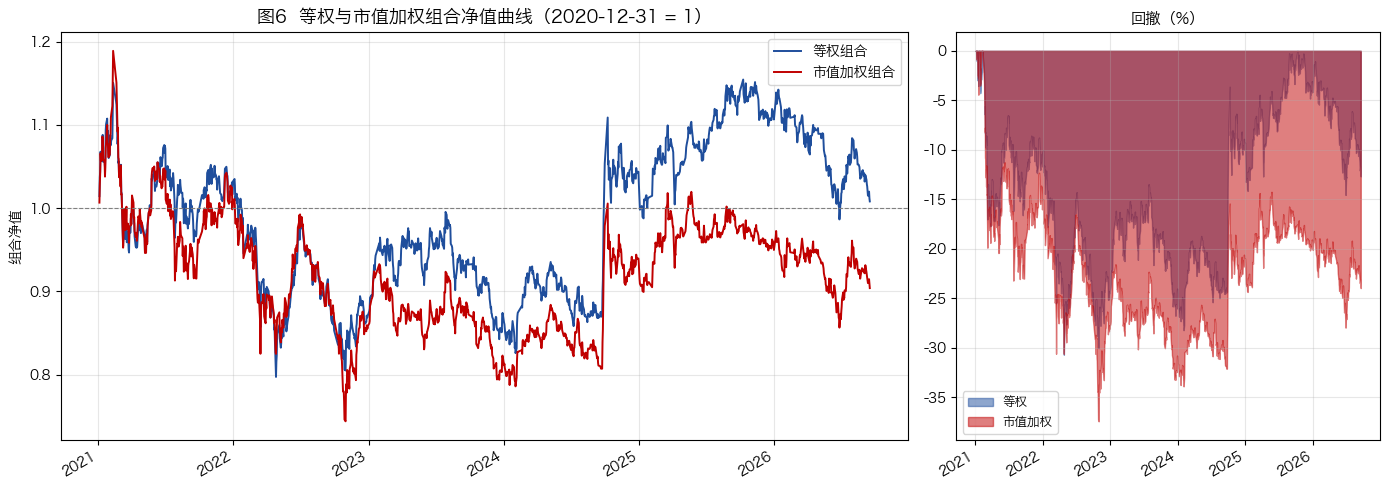

,等权组合,市值加权组合
累计净值,1.01,0.90
几何年化收益(%),0.14,-1.82
年化波动(%),16.85,17.35
最大回撤(%),30.70,37.43


In [13]:
# ---- 组合绩效 ----
def perf(r, label):
    nav = (1 + r).cumprod()
    T = len(r)
    ann = nav.iloc[-1] ** (252 / T) - 1
    vol = r.std() * np.sqrt(252)
    mdd = -(nav / nav.cummax() - 1).min()
    return pd.Series({'累计净值': nav.iloc[-1], '几何年化收益(%)': ann * 100,
                      '年化波动(%)': vol * 100, '最大回撤(%)': mdd * 100}, name=label)

NAV_ew = (1 + r_ew).cumprod(); NAV_vw = (1 + r_vw).cumprod()
perf_tbl = pd.concat([perf(r_ew, '等权组合'), perf(r_vw, '市值加权组合')], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [2, 1]})
ax = axes[0]
ax.plot(NAV_ew.index, NAV_ew, lw=1.4, color='#1f4e9c', label='等权组合')
ax.plot(NAV_vw.index, NAV_vw, lw=1.4, color='#c00000', label='市值加权组合')
ax.axhline(1.0, color='gray', ls='--', lw=0.8)
# 最大回撤发生区间标注
dd_ew = NAV_ew / NAV_ew.cummax() - 1; dd_vw = NAV_vw / NAV_vw.cummax() - 1
ax.set_title('图6  等权与市值加权组合净值曲线（2020-12-31 = 1）', fontsize=13)
ax.set_ylabel('组合净值'); ax.legend(fontsize=10); ax.grid(alpha=0.3)
ax2 = axes[1]
ax2.fill_between(dd_ew.index, dd_ew * 100, 0, color='#1f4e9c', alpha=0.5, label='等权')
ax2.fill_between(dd_vw.index, dd_vw * 100, 0, color='#c00000', alpha=0.5, label='市值加权')
ax2.set_title('回撤（%）', fontsize=11); ax2.legend(fontsize=9); ax2.grid(alpha=0.3)
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.savefig('figs/fig6-portfolio.png', dpi=150, bbox_inches='tight')
plt.show()

perf_tbl.round(2)

### Step 3：结果解读

| 指标 | 等权组合 | 市值加权组合 |
|---|---|---|
| 累计净值 | 1.01 | 0.90 |
| 几何年化收益 | **+0.14%** | **−1.82%** |
| 年化波动 | 16.85% | 17.35% |
| 最大回撤 | 30.70% | 37.43% |

- **等权全面占优**：年化收益高约 2 个百分点（+0.14% 对 −1.82%），波动更低（16.85% 对 17.35%），最大回撤更浅（30.7% 对 37.4%）。等权组合期末净值勉强保住 1.01，市值加权净亏约 10%。
- **差异来源**：市值加权把约 50% 的权重给了茅台 + 招行两只超大市值股票（33.6% + 16.1%），而茅台样本期年化 −4.9%、招行 +2.6%，权重集中放大了大市值股票的拖累；等权则给隆基、恒瑞等负收益股票与长电、比亚迪等正收益股票同等权重——本样本中后者恰好抵消了前者。此外，2021 年初建仓时点恰逢核心资产（大市值白马）估值顶部（两组合净值峰值均出现在 2021-02-10），市值加权天然重仓该类资产，随后承受了更深的回撤（−37.4%，谷底在 2022-10-31；等权 −30.7%，谷底在 2022-04-26）。
- **分散化效果**：两组合年化波动（16.9%、17.4%）均显著低于 10 只股票的平均年化波动（约 28.3%），印证相关系数为正但远小于 1 时分散投资仍能大幅降低波动。
- **局限**：这是**事后选定样本**的表现，不代表历史可实施策略或未来收益；忽略交易成本、停牌处理采用"剔除后归一"的近似、市值校准法假设网格间隔内股本不变，均会在边际上影响数值，但不改变"等权优于市值加权"的方向性结论（差异约 2 个百分点/年，远超方法误差量级）。

## 7. 总体结论

本作业以 10 只覆盖 8 个申万一级行业的 A 股龙头为样本，用 2021-01-04 至 2026-09-16（1384 个交易日）的冻结数据分析收益、风险与组合表现，主要结论如下：

1. **风险收益横截面差异大且普遍不匹配**。年化收益从长江电力的 +8.4% 到隆基绿能的 −22.3% 不等；波动率从 13.1%（长电）到 41.8%（科大讯飞/隆基）。样本期横跨 2021 年核心资产泡沫顶点与随后的长期调整，多数高波动成长股"承担了高风险却未获得收益补偿"，唯一的高收益低波动组合是防御型的长江电力。

2. **收益分布厚尾右偏，极端日集中于市场剧震期**。10 只股票偏度均为正（0.09–0.92）、超额峰度均为正（1.9–6.1），正态假设会低估极端风险；2021 年初、2022 年 3–4 月、2024 年 9–10 月是全市场共性的高波动时段，20 日滚动年化波动率显示清晰的波动聚集与同涨同落。

3. **同行业相关性更高的猜想成立**。美的—格力相关系数 0.63 为全场最高，显著超过平均相关系数 0.27；长江电力与其余股票平均相关仅 0.12（与隆基、科大讯飞甚至略负），分散价值最大。绝大多数两两相关为正说明市场因子主导，纯多头组合无法消除系统性风险，但分散化仍使组合波动（16.9%）远低于个股均值（约 28%）。

4. **等权组合显著优于市值加权组合**。等权：年化 +0.14%、波动 16.85%、最大回撤 30.7%；市值加权：−1.82%、17.35%、37.4%。根源在于市值加权约 37% 的权重集中于茅台与招行，而 2021 年初恰是大市值白马的估值顶部，权重集中放大了其后的回撤。两组合波动均远低于个股均值（约 28.3%），验证了分散投资的作用。

**关键处理判断**：停牌（中信 6+1 天、长电 11+2 天）与复牌首日收益记缺失而非填零或跨日计算，组合权重当日剔除后归一；除权跳变通过后复权价正确处理并经股本校准交叉验证；日频总市值用"网格市值÷不复权价"校准股本构造，网格日重构误差在浮点精度级。

**数据与方法局限**：样本为事后选定的龙头组合，结论不代表可实施策略；行情依赖腾讯接口单一来源（东财限流未能交叉校验，但已用涨跌停制度与市值量级做合理性核验）；忽略交易成本与停牌期间的真实可交易性；市值校准法在网格间隔内的小额股本变动存在最多 5 个交易日的滞后。